# Modèle ML — Prédiction du Churn Télécom 
Adaptation du modèle de Nassim (Tunisie Télécom — Direction Régionale de Sousse) pour la plateforme MLOps : **plus de dépendance au Data Warehouse PostgreSQL** — les features sont reconstruites directement depuis les deux fichiers sources `parc.xlsx` (clients résiliés) et `derangements.xlsx` (incidents), uploadés dans le même zip que ce notebook.

In [1]:
!pip install openpyxl imbalanced-learn xgboost

In [2]:
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

print('=' * 60)
print('  MODÈLE ML — PRÉDICTION DU CHURN TÉLÉCOM')
print('=' * 60)

  MODÈLE ML — PRÉDICTION DU CHURN TÉLÉCOM


## Étape 1 : Extraction depuis les fichiers sources
Reproduit l'agrégation SQL du Data Warehouse avec pandas. Les en-têtes des fichiers Excel ont des espacements irréguliers (`W F  I D Ligne`, `État de l'alerte`…) : un résolveur de colonnes normalisé les retrouve de façon robuste.

In [3]:
def _norm(s):
    s = unicodedata.normalize('NFD', str(s))
    s = ''.join(ch for ch in s if unicodedata.category(ch) != 'Mn')
    return ''.join(s.lower().split())

def col(df, *keywords):
    """Première colonne dont le nom normalisé contient tous les mots-clés."""
    for c in df.columns:
        n = _norm(c)
        if all(_norm(k) in n for k in keywords):
            return c
    raise KeyError(f'Colonne introuvable: {keywords}')

print('\n[1/6] Extraction des données depuis les fichiers sources...')
parc = pd.read_excel('parc.xlsx')
der  = pd.read_excel('derangements.xlsx')
print(f'   parc.xlsx          : {len(parc)} clients résiliés')
print(f'   derangements.xlsx  : {len(der)} incidents')


[1/6] Extraction des données depuis les fichiers sources...
   parc.xlsx          : 1447 clients résiliés
   derangements.xlsx  : 8040 incidents


In [4]:
# Colonnes clés
C_LIGNE   = col(der, 'id', 'ligne')          # numéro de ligne (jointure)
C_OUV     = col(der, 'ouverture')            # date/heure d'ouverture
C_CLO     = col(der, 'cloture')              # date/heure de clôture
C_ALERTE  = col(der, 'alerte')               # état de l'alerte
C_CAT     = col(der, 'reclamation')          # catégorie réclamation
C_FSI_D   = col(der, 'fsi')                  # FSI (par incident)
C_DEBIT_D = col(der, 'debit')                # débit (par incident)
C_APPEL   = col(parc, 'appel')               # n° d'appel (clients résiliés)
C_FSI_P   = col(parc, 'fsi')
C_DEBIT_P = col(parc, 'debit')

# Durée de résolution en jours (équivalent duree_resolution_jours du DW)
der['_duree'] = (pd.to_datetime(der[C_CLO]) - pd.to_datetime(der[C_OUV])).dt.days
der['_duree'] = der['_duree'].clip(lower=0)

# Univers clients = lignes vues dans les incidents ∪ clients résiliés du parc.
# Le parc ne contient QUE des résiliés : le label churn = appartenance au parc.
resilies = set(parc[C_APPEL].astype('int64'))
lignes   = set(der[C_LIGNE].dropna().astype('int64'))
univers  = sorted(lignes | resilies)
base = pd.DataFrame({'id_client': univers})
base['churn'] = base['id_client'].isin(resilies).astype(int)

In [5]:
def mode_or(series, default):
    m = series.mode()
    return m.iloc[0] if len(m) else default

# Agrégats incidents par client (équivalents de la requête SQL du DW)
g = der.groupby(der[C_LIGNE].astype('int64'))
agg = pd.DataFrame({
    'nb_reclamations'         : g.size(),
    'delai_moy_resolution'    : g['_duree'].mean(),
    'delai_max_resolution'    : g['_duree'].max(),
    'delai_min_resolution'    : g['_duree'].min(),
    'delai_std_resolution'    : g['_duree'].std(),
    'nb_incidents_longs'      : g['_duree'].apply(lambda s: int((s > 10).sum())),
    'nb_non_resolus'          : g[C_ALERTE].apply(lambda s: int((s != 'Clôturée').sum())),
    'nb_categories_distinctes': g[C_CAT].nunique(),
    'categorie_dominante'     : g[C_CAT].apply(lambda s: mode_or(s, 'Aucune')),
    'fsi_incidents'           : g[C_FSI_D].apply(lambda s: mode_or(s.dropna(), None)),
    'debit_incidents'         : g[C_DEBIT_D].apply(lambda s: mode_or(s.dropna(), None)),
})

df = base.merge(agg, left_on='id_client', right_index=True, how='left')

# Clients du parc sans incident (LEFT JOIN du SQL) : features à zéro
for c in ['nb_reclamations', 'delai_moy_resolution', 'delai_max_resolution',
          'delai_min_resolution', 'delai_std_resolution',
          'nb_incidents_longs', 'nb_non_resolus', 'nb_categories_distinctes']:
    df[c] = df[c].fillna(0)
df['categorie_dominante'] = df['categorie_dominante'].fillna('Aucune')

In [6]:
# FSI et débit : priorité aux incidents, sinon au parc, sinon valeur neutre
parc_idx = parc.drop_duplicates(subset=[C_APPEL]).set_index(parc.drop_duplicates(subset=[C_APPEL])[C_APPEL].astype('int64'))
df['nom_fsi'] = (df['fsi_incidents']
                 .fillna(df['id_client'].map(parc_idx[C_FSI_P]))
                 .fillna('Inconnu'))
debit_txt = (df['debit_incidents']
             .fillna(df['id_client'].map(parc_idx[C_DEBIT_P]))
             .fillna('0').astype(str))

def parse_debit(txt):
    for d in (100, 50, 30, 20, 10, 8):
        if str(d) in txt:
            return d
    return 0

df['debit_num'] = debit_txt.map(parse_debit)
df = df.drop(columns=['fsi_incidents', 'debit_incidents'])

print(f'   Clients extraits   : {len(df)}')
print(f'   Churné (1)         : {df["churn"].sum()}')
print(f'   Actif  (0)         : {(df["churn"]==0).sum()}')
print(f'   Taux de churn      : {df["churn"].mean()*100:.1f}%')

   Clients extraits   : 4958
   Churné (1)         : 1440
   Actif  (0)         : 3518
   Taux de churn      : 29.0%


## Étape 2 : Feature engineering
(identique au modèle d'origine)

In [7]:
print('\n[2/6] Feature engineering...')

le_fsi = LabelEncoder()
le_cat = LabelEncoder()
df['fsi_encoded'] = le_fsi.fit_transform(df['nom_fsi'].astype(str))
df['cat_encoded'] = le_cat.fit_transform(df['categorie_dominante'].astype(str))
df['a_eu_reclamation']      = (df['nb_reclamations'] > 0).astype(int)
df['ratio_non_resolu']      = np.where(df['nb_reclamations']>0,
                                        df['nb_non_resolus']/df['nb_reclamations'], 0)
df['ratio_incidents_longs'] = np.where(df['nb_reclamations']>0,
                                        df['nb_incidents_longs']/df['nb_reclamations'], 0)
df['score_risque'] = (df['nb_reclamations']*2.0 + df['nb_non_resolus']*3.0 +
                      df['nb_incidents_longs']*1.5 + df['delai_moy_resolution']*0.3)

FEATURES = [
    'nb_reclamations', 'delai_moy_resolution', 'delai_max_resolution',
    'delai_min_resolution', 'delai_std_resolution', 'nb_incidents_longs',
    'nb_non_resolus', 'nb_categories_distinctes', 'a_eu_reclamation',
    'ratio_non_resolu', 'ratio_incidents_longs', 'score_risque',
    'debit_num', 'fsi_encoded', 'cat_encoded'
]

X = df[FEATURES].fillna(0)
y = df['churn']
print(f'   Features utilisées : {len(FEATURES)}')


[2/6] Feature engineering...
   Features utilisées : 15


## Étape 3 : Split + SMOTE

In [8]:
print('\n[3/6] Split 80/20 + SMOTE...')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'   Train avant SMOTE  : {dict(y_train.value_counts())}')
print(f'   Train après SMOTE  : {dict(pd.Series(y_train_sm).value_counts())}')
print(f'   Test               : {dict(y_test.value_counts())}')


[3/6] Split 80/20 + SMOTE...
   Train avant SMOTE  : {0: np.int64(2814), 1: np.int64(1152)}
   Train après SMOTE  : {0: np.int64(2814), 1: np.int64(2814)}
   Test               : {0: np.int64(704), 1: np.int64(288)}


## Étape 4 : Entraînement XGBoost
(hyperparamètres identiques au modèle d'origine)

In [9]:
print('\n[4/6] Entraînement XGBoost...')

xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    gamma=1, reg_alpha=0.1, reg_lambda=1,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb.fit(X_train_sm, y_train_sm)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X_train_sm, y_train_sm, cv=cv, scoring='roc_auc')
print(f'   AUC-ROC CV 5-fold  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')


[4/6] Entraînement XGBoost...
   AUC-ROC CV 5-fold  : 0.9400 ± 0.0049


## Étape 5 : Évaluation + visualisations


[5/6] Évaluation et visualisation...


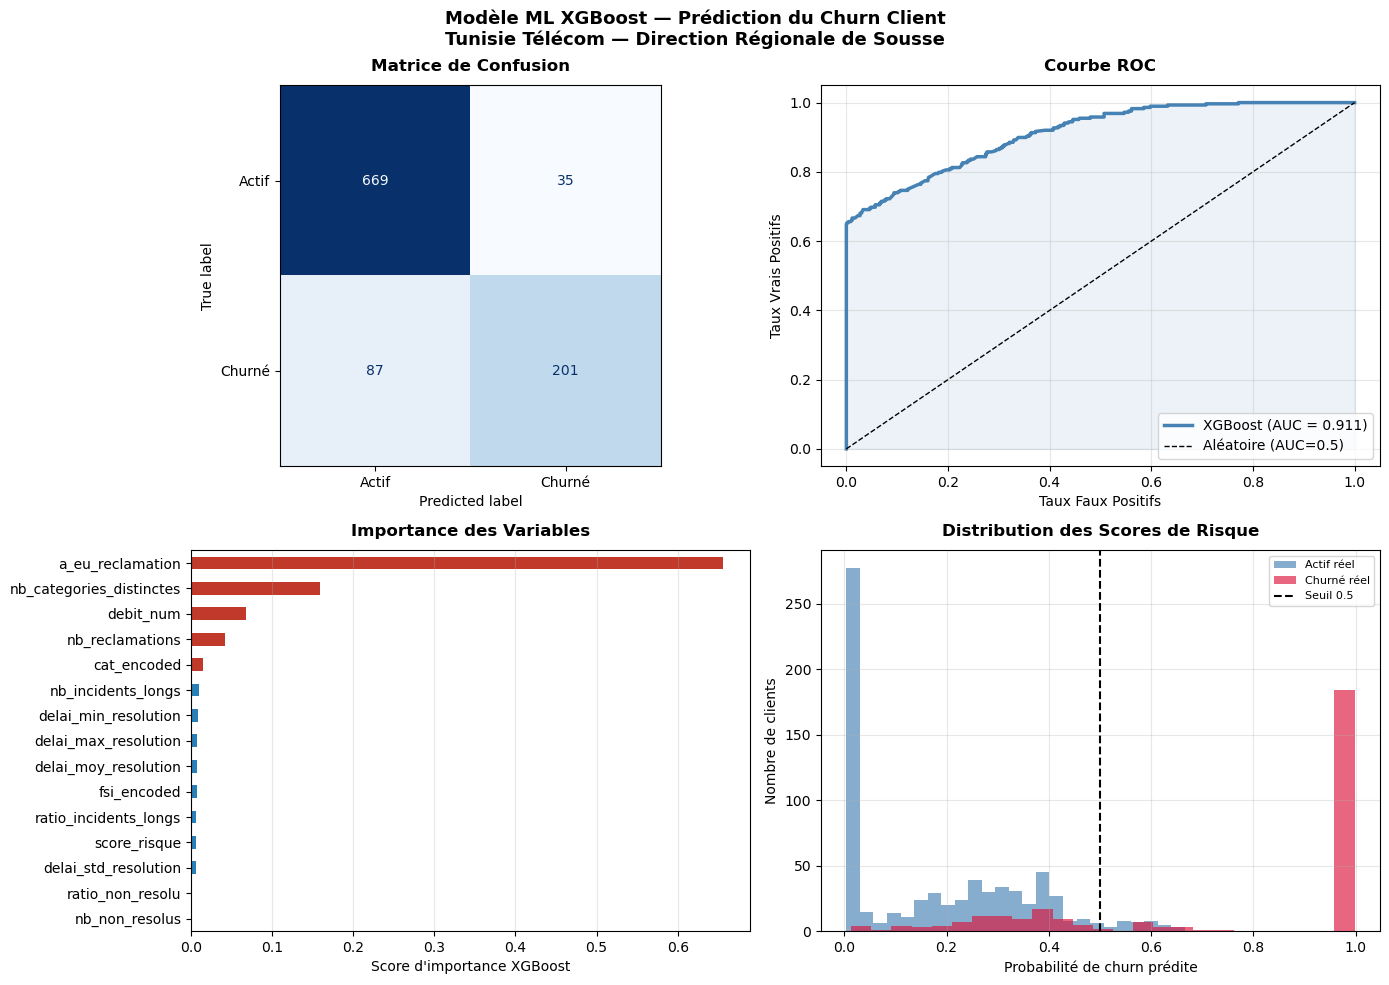

   Figures sauvegardées : ml_churn_evaluation.png


In [10]:
print('\n[5/6] Évaluation et visualisation...')

y_pred      = xgb.predict(X_test)
y_pred_prob = xgb.predict_proba(X_test)[:, 1]
auc         = roc_auc_score(y_test, y_pred_prob)
acc         = (y_pred == y_test).mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Modèle ML XGBoost — Prédiction du Churn Client\n'
             'Tunisie Télécom — Direction Régionale de Sousse',
             fontsize=13, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Actif', 'Churné'])
disp.plot(ax=axes[0, 0], colorbar=False, cmap='Blues')
axes[0, 0].set_title('Matrice de Confusion', fontweight='bold', pad=10)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[0, 1].plot(fpr, tpr, color='steelblue', lw=2.5,
                label=f'XGBoost (AUC = {auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire (AUC=0.5)')
axes[0, 1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0, 1].set_xlabel('Taux Faux Positifs')
axes[0, 1].set_ylabel('Taux Vrais Positifs')
axes[0, 1].set_title('Courbe ROC', fontweight='bold', pad=10)
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(alpha=0.3)

imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values()
colors = ['#c0392b' if v >= imp.quantile(0.7) else '#2980b9' for v in imp]
imp.plot(kind='barh', ax=axes[1, 0], color=colors)
axes[1, 0].set_title('Importance des Variables', fontweight='bold', pad=10)
axes[1, 0].set_xlabel("Score d'importance XGBoost")
axes[1, 0].grid(alpha=0.3, axis='x')

df_viz = pd.DataFrame({'prob': y_pred_prob, 'reel': y_test.values})
axes[1, 1].hist(df_viz[df_viz['reel']==0]['prob'], bins=25, alpha=0.65,
                color='steelblue', label='Actif réel')
axes[1, 1].hist(df_viz[df_viz['reel']==1]['prob'], bins=25, alpha=0.65,
                color='crimson', label='Churné réel')
axes[1, 1].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Seuil 0.5')
axes[1, 1].set_xlabel('Probabilité de churn prédite')
axes[1, 1].set_ylabel('Nombre de clients')
axes[1, 1].set_title('Distribution des Scores de Risque', fontweight='bold', pad=10)
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ml_churn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Figures sauvegardées : ml_churn_evaluation.png')

## Étape 6 : Export des scores
Sans Data Warehouse : les scores sont exportés en CSV au lieu d'un UPDATE SQL sur `dw.dim_client`.

In [11]:
print('\n[6/6] Export des scores en CSV...')

prob_all = xgb.predict_proba(X)[:, 1]
df['score_churn'] = prob_all.round(4)
df['risque_ml']   = pd.cut(prob_all, bins=[0, 0.3, 0.6, 1.0],
                           labels=['Faible', 'Moyen', 'Haut'])
df[['id_client', 'churn', 'score_churn', 'risque_ml']].to_csv(
    'scores_churn.csv', index=False)
print('   Scores exportés dans scores_churn.csv ✓')

print('\n' + '=' * 60)
print('  SEGMENTATION CLIENTS PAR RISQUE DE CHURN')
print('=' * 60)
resume = df.groupby('risque_ml', observed=True).agg(
    nb_clients  = ('id_client', 'count'),
    churne_reel = ('churn', 'sum'),
    taux_churn  = ('churn', 'mean'),
    score_moyen = ('score_churn', 'mean')
).round(3)
resume['taux_churn'] = (resume['taux_churn']*100).round(1)
resume.columns = ['Nb Clients', 'Churné Réel', 'Taux Churn %', 'Score Moyen']
print(resume.to_string())

print('\n' + '=' * 60)
print("  MÉTRIQUES D'ÉVALUATION DU MODÈLE XGBOOST")
print('=' * 60)
print(classification_report(y_test, y_pred,
      target_names=['Actif (0)', 'Churné (1)']))
print(f'  Accuracy           : {acc:.4f}')
print(f'  AUC-ROC final      : {auc:.4f}')
print(f'  AUC-ROC CV 5-fold  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('=' * 60)
print('\n  MODÈLE TERMINÉ AVEC SUCCÈS')


[6/6] Export des scores en CSV...
   Scores exportés dans scores_churn.csv ✓

  SEGMENTATION CLIENTS PAR RISQUE DE CHURN
           Nb Clients  Churné Réel  Taux Churn %  Score Moyen
risque_ml                                                    
Faible           2620          123           4.7        0.097
Moyen            1342          359          26.8        0.403
Haut              996          958          96.2        0.966

  MÉTRIQUES D'ÉVALUATION DU MODÈLE XGBOOST
              precision    recall  f1-score   support

   Actif (0)       0.88      0.95      0.92       704
  Churné (1)       0.85      0.70      0.77       288

    accuracy                           0.88       992
   macro avg       0.87      0.82      0.84       992
weighted avg       0.88      0.88      0.87       992

  Accuracy           : 0.8770
  AUC-ROC final      : 0.9114
  AUC-ROC CV 5-fold  : 0.9400 ± 0.0049

  MODÈLE TERMINÉ AVEC SUCCÈS


---
**Sur la plateforme** : ce run apparaît dans l'onglet *Experiments* (famille XGBoost) avec l'AUC/accuracy d'évaluation ; le modèle peut ensuite être enregistré, promu et déployé. Les fits de la validation croisée peuvent créer quelques runs supplémentaires — c'est normal.